# Assignment 1 - Building a Vision Model with Keras

In this assignment, you will build a simple vision model using Keras. The goal is to classify images from the Fashion MNIST dataset, which contains images of clothing items.

You will:
1. Load and inspect the Fashion MNIST dataset.
2. Run a simple baseline model to establish a performance benchmark.
3. Build and evaluate a simple CNN model, choosing appropriate loss and metrics.
4. Design and run controlled experiments on one hyperparameter (e.g., number of filters, kernel size, etc.) and one regularization technique (e.g., dropout, L2 regularization).
5. Analyze the results and visualize the model's performance.

# 1. Loading and Inspecting the Dataset

Fashion MNIST is a dataset of grayscale images of clothing items, with 10 classes. Each image is 28x28 pixels, like the MNIST dataset of handwritten digits. Keras provides a convenient way to load this dataset. 

In this section, you should:

- [ ] Inspect the shapes of the training and test sets to confirm their size and structure.
- [ ] Convert the labels to one-hot encoded format if necessary. (There is a utility function in Keras for this.)
- [ ] Visualize a few images from the dataset to understand what the data looks like.

In [1]:
from tensorflow.keras.datasets import fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalize the pixel values to be between 0 and 1
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Classes in the Fashion MNIST dataset
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [2]:
# Inspect the shapes of the datasets
print("X_train shape is ", X_train.shape)
print("y_train shape is ", y_train.shape)
print("X_test shape is ", X_test.shape)
print("y_test shape is ", y_test.shape)

X_train shape is  (60000, 28, 28)
y_train shape is  (60000,)
X_test shape is  (10000, 28, 28)
y_test shape is  (10000,)


In [3]:
# Convert labels to one-hot encoding
from tensorflow.keras.utils import to_categorical

y_train_onehot = to_categorical(y_train, num_classes=len(class_names))
y_test_onehot = to_categorical(y_test, num_classes=len(class_names))

print(y_train_onehot.shape, y_test_onehot.shape)

(60000, 10) (10000, 10)


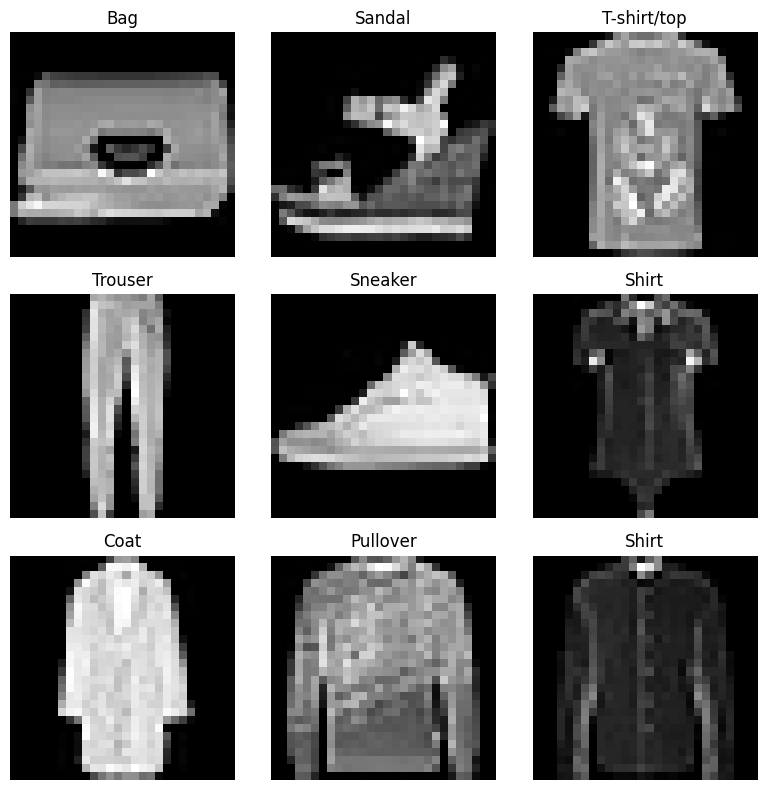

In [4]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 8))
indices = np.random.choice(len(X_train), 9, replace=False)

for i, idx in enumerate(indices):
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_train[idx], cmap="gray")
    plt.title(class_names[y_train[idx]])
    plt.axis("off")

plt.tight_layout()
plt.show()


Reflection: Does the data look as expected? How is the quality of the images? Are there any issues with the dataset that you notice?

**Your answer here**
Based on 9 samples above, the labels and data are match. The quality of the images is good, much better than MNIST 8x8. I think the data is better than 8x8 MNIST data, but they are still blurr and the color is black and white.

# 2. Baseline Model

In this section, you will create a linear regression model as a baseline. This model will not use any convolutional layers, but it will help you understand the performance of a simple model on this dataset.
You should:
- [ ] Create a simple linear regression model using Keras.
- [ ] Compile the model with an appropriate loss function and optimizer.
- [ ] Train the model on the training set and evaluate it on the test set.

A linear regression model can be created using the `Sequential` API in Keras. Using a single `Dense` layer with no activation function is equivalent to a simple linear regression model. Make sure that the number of units in the output layer matches the number of classes in the dataset.

Note that for this step, we will need to use `Flatten` to convert the 2D images into 1D vectors before passing them to the model. Put a `Flatten()` layer as the first layer in your model so that the 2D image data can be flattened into 1D vectors.

In [5]:
from keras.models import Sequential
from keras.layers import Dense, Flatten, Input

# Create a simple linear regression model
model = Sequential()
# You can use `model.add(<layer>)` to add layers to the model
model = Sequential([
    Input(shape=(28, 28)),    
    Flatten(),                 
    Dense(len(class_names))    
])

# Compile the model using `model.compile()`
model.compile(optimizer='adam',
              loss='mean_squared_error',
              metrics=['accuracy'])

# Train the model with `model.fit()`
history = model.fit(X_train, y_train_onehot,
                    epochs=10,
                    batch_size=64,
                    validation_split=0.15,
                    verbose=1)

# Evaluate the model with `model.evaluate()`
test_loss, test_acc = model.evaluate(X_test, y_test_onehot, verbose=1)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Epoch 1/10
797/797 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6153 - loss: 0.0873 - val_accuracy: 0.7891 - val_loss: 0.0459
Epoch 2/10
797/797 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7969 - loss: 0.0433 - val_accuracy: 0.7957 - val_loss: 0.0431
Epoch 3/10
797/797 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8085 - loss: 0.0403 - val_accuracy: 0.8121 - val_loss: 0.0391
Epoch 4/10
797/797 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8178 - loss: 0.0387 - val_accuracy: 0.8231 - val_loss: 0.0378
Epoch 5/10
797/797 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8184 - loss: 0.0382 - val_accuracy: 0.8141 - val_loss: 0.0392
Epoch 6/10
797/797 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8208 - loss: 0.0379 - val_accuracy: 0.8076 - val_loss: 0.0382
Epoch 7/10
797/797 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8160 - loss: 0.0379 - val_accuracy: 0.8170 - val_loss: 0.0380
Epoch 8/10
797/797 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8215 - loss: 0.0375 - val_accuracy: 0.

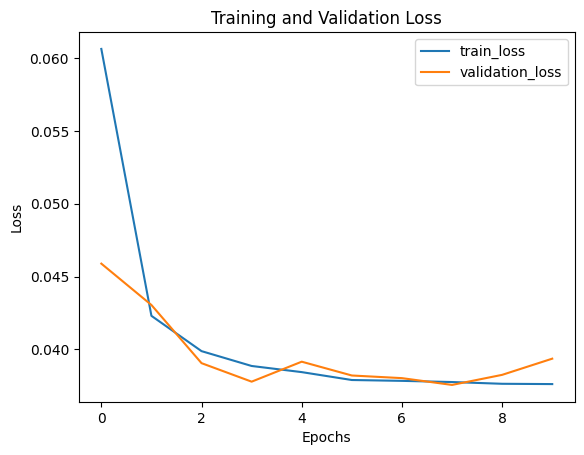

In [6]:
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='validation_loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

Reflection: What is the performance of the baseline model? How does it compare to what you expected? Why do you think the performance is at this level?

**Your answer here**
I think based on the trend where the loss of training is decreasing then the loss of validation is decreasing too, it means there is no overfitting. The baseline model actually doing good. I expect the performance worse than this, but it is quit good. It is actually linear regression and the result already good. I think with CNN the result will be better.

# 3. Building and Evaluating a Simple CNN Model

In this section, you will build a simple Convolutional Neural Network (CNN) model using Keras. A convolutional neural network is a type of deep learning model that is particularly effective for image classification tasks. Unlike the basic neural networks we have built in the labs, CNNs can accept images as input without needing to flatten them into vectors.

You should:
- [ ] Build a simple CNN model with at least one convolutional layer (to learn spatial hierarchies in images) and one fully connected layer (to make predictions).
- [ ] Compile the model with an appropriate loss function and metrics for a multi-class classification problem.
- [ ] Train the model on the training set and evaluate it on the test set.

Convolutional layers are designed to accept inputs with three dimensions: height, width and channels (e.g., RGB for color images). For grayscale images like those in Fashion MNIST, the input shape will be (28, 28, 1).

When you progress from the convolutional layers to the fully connected layers, you will need to flatten the output of the convolutional layers. This can be done using the `Flatten` layer in Keras, which doesn't require any parameters.

In [7]:
from keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense

# Reshape the data to include the channel dimension
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Create a simple CNN model
model_CNN = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),  
    MaxPooling2D(pool_size=(2, 2)),                                 
    Conv2D(64, (3, 3), activation='relu'),                         
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),                                                      
    Dense(128, activation='relu'),                                  
    Dropout(0.3),                                                   
    Dense(len(class_names), activation='softmax')                   
])

# Train the model
model_CNN.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history_CNN = model_CNN.fit(X_train, y_train_onehot,
                        epochs=10,
                        batch_size=64,
                        validation_split=0.15,
                        verbose=1)

# Evaluate the model
test_loss, test_acc = model_CNN.evaluate(X_test, y_test_onehot, verbose=1)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Epoch 1/10


C:\Users\ekadw\anaconda3\envs\Tensorflow31018\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


797/797 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.7118 - loss: 0.7939 - val_accuracy: 0.8703 - val_loss: 0.3629
Epoch 2/10
797/797 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.8673 - loss: 0.3703 - val_accuracy: 0.8811 - val_loss: 0.3271
Epoch 3/10
797/797 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.8880 - loss: 0.3095 - val_accuracy: 0.8897 - val_loss: 0.2881
Epoch 4/10
797/797 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.8970 - loss: 0.2791 - val_accuracy: 0.8979 - val_loss: 0.2671
Epoch 5/10
797/797 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9054 - loss: 0.2538 - val_accuracy: 0.9014 - val_loss: 0.2679
Epoch 6/10
797/797 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9140 - loss: 0.2344 - val_accuracy: 0.9013 - val_loss: 0.2588
Epoch 7/10
797/797 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9212 - loss: 0.2157 - val_accuracy: 0.9138 - val_loss: 0.2404
Epoch 8/10
797/797 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9262 - loss: 0.2005 - val_accurac

Text(0, 0.5, 'Loss')

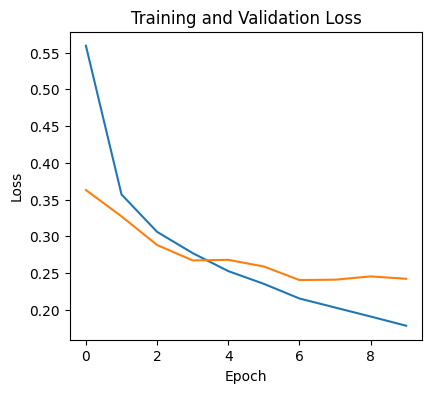

In [8]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history_CNN.history['loss'], label='train_loss')
plt.plot(history_CNN.history['val_loss'], label='validation_loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

Reflection: Did the CNN model perform better than the baseline model? If so, by how much? What do you think contributed to this improvement?

**Your answer here**
CNN model perform better than the baseline model where baseline model accuracy is 0.81, meanwhile the CNN accuracy is 0.91. The nonlinearity contribute better in the performace.

# 4. Designing and Running Controlled Experiments

In this section, you will design and run controlled experiments to improve the model's performance. You will focus on one hyperparameter and one regularization technique.
You should:
- [ ] Choose one hyperparameter to experiment with (e.g., number of filters, kernel size, number of layers, etc.) and one regularization technique (e.g., dropout, L2 regularization). For your hyperparameter, you should choose at least three different values to test (but there is no upper limit). For your regularization technique, simply test the presence or absence of the technique.
- [ ] Run experiments by modifying the model architecture or hyperparameters, and evaluate the performance of each model on the test set.
- [ ] Record the results of your experiments, including the test accuracy and any other relevant metrics.
- [ ] Visualize the results of your experiments using plots or tables to compare the performance of different models.

The best way to run your experiments is to create a `for` loop that iterates over a range of values for the hyperparameter you are testing. For example, if you are testing different numbers of filters, you can create a loop that runs the model with 32, 64, and 128 filters. Within the loop, you can compile and train the model, then evaluate it on the test set. After each iteration, you can store the results in a list or a dictionary for later analysis.

Note: It's critical that you re-initialize the model (by creating a new instance of the model) before each experiment. If you don't, the model will retain the weights from the previous experiment, which can lead to misleading results.

In [9]:
# A. Test Hyperparameters

In [10]:
# B. Test presence or absence of regularization

In [11]:
def cnn_hyperparameters(num_filters=32, use_dropout=True):
    model_hyper = Sequential([
        Input(shape=(28, 28, 1)),
        Conv2D(num_filters, (3, 3), activation='relu'),
        MaxPooling2D(pool_size=(2, 2)),
        Conv2D(num_filters * 2, (3, 3), activation='relu'),
        MaxPooling2D(pool_size=(2, 2)),
        Flatten(),
        Dense(128, activation='relu')
    ])
    
    if use_dropout:
        model_hyper.add(Dropout(0.3))
    
    model_hyper.add(Dense(len(class_names), activation='softmax'))
    
    model_hyper.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model_hyper

In [12]:
filter_values = [32, 64, 128]
dropout_options = [True, False]
results = []

for num_filters in filter_values:
    for use_dropout in dropout_options:
        print(f"\n Testing model with {num_filters} filters, dropout={use_dropout}")
        model_hyper = cnn_hyperparameters(num_filters=num_filters, use_dropout=use_dropout)
        
        # Train model
        history_hyper = model_hyper.fit(X_train, y_train_onehot,
                                    epochs=5,            
                                    batch_size=64,
                                    validation_split=0.15,
                                    verbose=1)
        
        # Evaluate on test set
        test_loss, test_acc = model_hyper.evaluate(X_test, y_test_onehot, verbose=0)
        
        # Store results
        results.append({
            'filters': num_filters,
            'dropout': use_dropout,
            'test_loss': test_loss,
            'test_acc': test_acc
        })
        
        print(f"Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")


 Testing model with 32 filters, dropout=True
Epoch 1/5
797/797 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - accuracy: 0.7093 - loss: 0.7992 - val_accuracy: 0.8578 - val_loss: 0.3976
Epoch 2/5
797/797 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.8584 - loss: 0.3894 - val_accuracy: 0.8786 - val_loss: 0.3337
Epoch 3/5
797/797 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.8806 - loss: 0.3299 - val_accuracy: 0.8866 - val_loss: 0.3047
Epoch 4/5
797/797 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.8950 - loss: 0.2899 - val_accuracy: 0.8866 - val_loss: 0.2998
Epoch 5/5
797/797 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.9000 - loss: 0.2734 - val_accuracy: 0.8993 - val_loss: 0.2731
Test Accuracy: 0.8971, Test Loss: 0.2799

 Testing model with 32 filters, dropout=False
Epoch 1/5
797/797 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.7538 - loss: 0.6892 - val_accuracy: 0.8599 - val_loss: 0.3873
Epoch 2/5
797/797 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.8739 - loss: 0.3471 - val

In [13]:
# Result:
import pandas as pd

results_df = pd.DataFrame(results)
print("\n Hyperparameters experiment results:")
print(results_df)


 Hyperparameters experiment results:
   filters  dropout  test_loss  test_acc
0       32     True   0.279926    0.8971
1       32    False   0.279907    0.8968
2       64     True   0.261118    0.9065
3       64    False   0.259975    0.9073
4      128     True   0.248551    0.9093
5      128    False   0.245347    0.9129


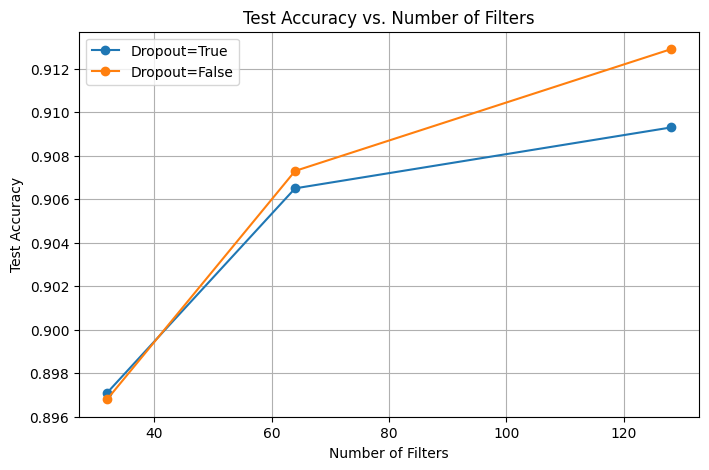

In [14]:
plt.figure(figsize=(8,5))
for dropout in dropout_options:
    subset = results_df[results_df['dropout'] == dropout]
    plt.plot(subset['filters'], subset['test_acc'], marker='o', label=f"Dropout={dropout}")
plt.title("Test Accuracy vs. Number of Filters")
plt.xlabel("Number of Filters")
plt.ylabel("Test Accuracy")
plt.legend()
plt.grid(True)
plt.show()

Reflection: Report on the performance of the models you tested. Did any of the changes you made improve the model's performance? If so, which ones? What do you think contributed to these improvements? Finally, what combination of hyperparameters and regularization techniques yielded the best performance?

**Your answer here**
Based on figure and table above, drop out will make the accuracy is decreasing except for the 32 number of filters, but the scale is minimum. With less risk of overfitting we sacrifice performance a little bit. Then by incerasing the number of filters, the accuracy is getting better. This is caused by more neuron is added it means more complex the model is and the better the model performance. I think the best combination to decrease the probability of overfitting are drop out and increase the number of filters.

# 5. Training Final Model and Evaluation

In this section, you will train the final model using the best hyperparameters and regularization techniques you found in the previous section. You should:
- [ ] Compile the final model with the best hyperparameters and regularization techniques.
- [ ] Train the final model on the training set and evaluate it on the test set.
- [ ] Report the final model's performance on the test set, including accuracy and any other relevant metrics.

## Construct the Final Model

In [15]:
# Identify the best parameters
best_result_max = results_df.loc[results_df['test_acc'].idxmax()]
best_filters = int(best_result_max['filters'])
best_dropout = bool(True)

In [16]:
best_dropout

True

In [17]:
# Create the final model based on the best parameters
final_model = cnn_hyperparameters(num_filters=best_filters, use_dropout=best_dropout)

In [18]:
# Compile the final model
final_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [19]:
# Train the final model
history_final = final_model.fit(
    X_train, y_train_onehot,
    epochs=10,
    batch_size=64,
    validation_split=0.15,
    verbose=1
)

Epoch 1/10
797/797 ━━━━━━━━━━━━━━━━━━━━ 69s 85ms/step - accuracy: 0.7509 - loss: 0.6936 - val_accuracy: 0.8773 - val_loss: 0.3327
Epoch 2/10
797/797 ━━━━━━━━━━━━━━━━━━━━ 67s 84ms/step - accuracy: 0.8748 - loss: 0.3413 - val_accuracy: 0.8926 - val_loss: 0.2894
Epoch 3/10
797/797 ━━━━━━━━━━━━━━━━━━━━ 68s 85ms/step - accuracy: 0.8968 - loss: 0.2856 - val_accuracy: 0.8984 - val_loss: 0.2634
Epoch 4/10
797/797 ━━━━━━━━━━━━━━━━━━━━ 67s 84ms/step - accuracy: 0.9105 - loss: 0.2439 - val_accuracy: 0.9094 - val_loss: 0.2441
Epoch 5/10
797/797 ━━━━━━━━━━━━━━━━━━━━ 69s 87ms/step - accuracy: 0.9180 - loss: 0.2200 - val_accuracy: 0.9140 - val_loss: 0.2369
Epoch 6/10
797/797 ━━━━━━━━━━━━━━━━━━━━ 67s 84ms/step - accuracy: 0.9271 - loss: 0.1931 - val_accuracy: 0.9153 - val_loss: 0.2428
Epoch 7/10
797/797 ━━━━━━━━━━━━━━━━━━━━ 76s 95ms/step - accuracy: 0.9377 - loss: 0.1685 - val_accuracy: 0.9207 - val_loss: 0.2414
Epoch 8/10
797/797 ━━━━━━━━━━━━━━━━━━━━ 83s 104ms/step - accuracy: 0.9416 - loss: 0.1560 -

In [20]:
# Evaluate on the test set
test_loss, test_acc = final_model.evaluate(X_test, y_test_onehot, verbose=1)
print(f"\n Final Model Test Accuracy: {test_acc:.4f}")
print(f"Final Model Test Loss: {test_loss:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.9083 - loss: 0.2799

 Final Model Test Accuracy: 0.9123
Final Model Test Loss: 0.2619


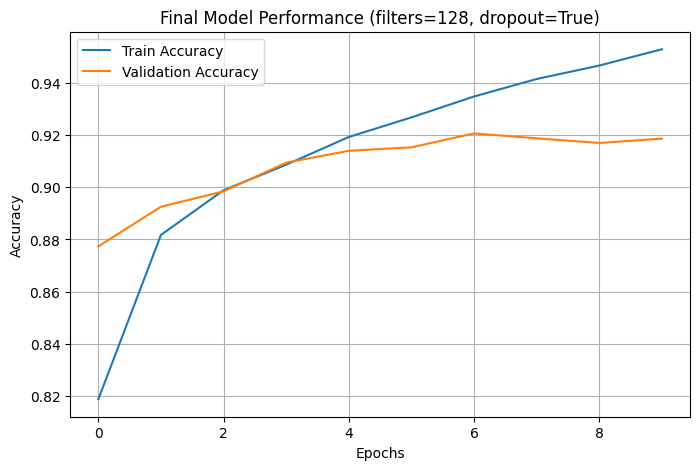

In [21]:
plt.figure(figsize=(8,5))
plt.plot(history_final.history['accuracy'], label='Train Accuracy')
plt.plot(history_final.history['val_accuracy'], label='Validation Accuracy')
plt.title(f"Final Model Performance (filters={best_filters}, dropout={best_dropout})")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

Reflection: How does the final model's performance compare to the baseline and the CNN model? What do you think contributed to the final model's performance? If you had time, what other experiments would you run to further improve the model's performance?

**Your answer here**
The final model performance is the best compare to the baseline and CNN model. This is caused by the best parameter possible that we use in the final model. Further improvement is by doing another hyperparameter optimization with all posible parameters such as kernel, loss functions, drop out rate, etc. Beside those, I need to check the distribution of target. Because if there is imbalance in the dataset, the high accuracy as performance metric is useless since in imbalance dataset, model will tends to discriminate the minority target. I think I will do the distribution testing after this.

But From the figure above, I find out the model is overfitting. We need to increase the drop out rate to handle this problem. But the difference is only 3%, I think we are safe here.

## Find out the distribution of targets

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Count occurrences of each class
unique, counts = np.unique(y_train, return_counts=True)

# Combine into a dictionary for easy viewing
class_distribution = dict(zip(class_names, counts))
print("Class Distribution in Training Set:\n")
for name, count in class_distribution.items():
    print(f"{name:15s}: {count}")

Class Distribution in Training Set:

T-shirt/top    : 6000
Trouser        : 6000
Pullover       : 6000
Dress          : 6000
Coat           : 6000
Sandal         : 6000
Shirt          : 6000
Sneaker        : 6000
Bag            : 6000
Ankle boot     : 6000


Because the number of images for each target are the same (all of them are 6000 each), then there is no imbalance dataset here.

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.
### Submission Parameters:
* Submission Due Date: `23:59 PM - 26/10/2025`
* The branch name for your repo should be: `assignment-1`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_1.ipynb)
    * The Lab 1 notebook (labs/lab_1.ipynb)
    * The Lab 2 notebook (labs/lab_2.ipynb)
    * The Lab 3 notebook (labs/lab_3.ipynb)
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/deep_learning/pull/<pr_id>`
* Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.
Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.
If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-7-help-ml`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.